# Fotopletismografía (PPG) a partir de video

Extracción de una señal fotopletismográfica y de la frecuencia cardiaca a partir de un video
convencional. Cada cuadro del video es una muestra y los cuadros por segundo son la frecuencia
de muestreo: promediando la saturación en el canal rojo de cada cuadro se reconstruye la señal
de pulso, cuya frecuencia dominante se localiza por FFT y se confirma por detección de picos.

Registro analizado: prueba a **100 LPM**.

*Procesamiento Digital de Señales Biomédicas — UAM.*


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Librería de procesamiento de imágenes y videos
import cv2

import scipy.io
from numpy.fft import fft, fftfreq, fftshift, ifft

from scipy.signal import find_peaks

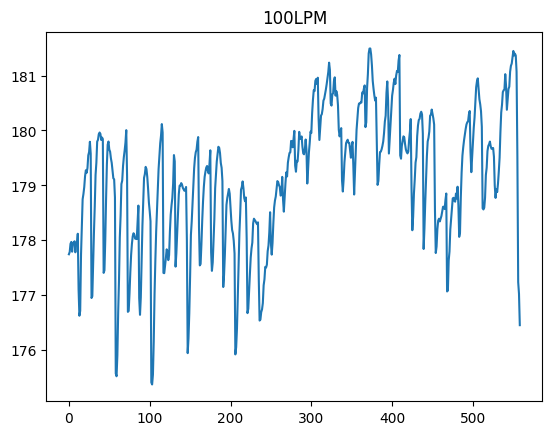

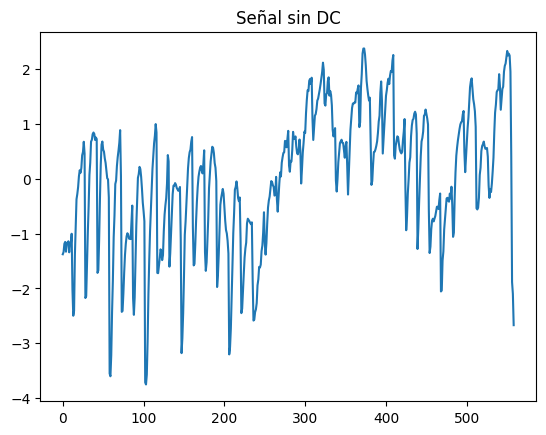

In [ ]:
video = cv2.VideoCapture('/content/drive/MyDrive/PPG_videos/v10-100LPM.avi') #Ruta del video

#Número de imágenes (frames) del video = Número de muestras de la señal
N = video.get(cv2.CAP_PROP_FRAME_COUNT)

#Cuadros por segundo del video = frecuencia de muestreo de la señal
fps = video.get(cv2.CAP_PROP_FPS)

#Bandera de control que interrumpe el ciclo while
ret = True

#Lista para guardar el promedio de la saturación (en rojo) de cada imagen del video
HSV_promedio = []

while ret:
    ret, frame = video.read()
    if not ret: break                                                             # Variable de control. Cuando no hay más imágenes en el video, el ciclo se termina

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)[:,:,2]                           # Conversión de la imagen RGB a HSV. Selección del canal rojo
    mean_hsv_values = np.sum(np.sum(hsv, axis=0),axis=0)/hsv.size                 # Valor promedio de la saturación de rojo en la imagen actual
    HSV_promedio.append(mean_hsv_values)                                          # Se almacena el valor promedio en la lista HSV_promedio


#Se convierte la lista en un arreglo numérico de numpy
signal = np.array(HSV_promedio).flatten()
plt.plot(signal)
plt.title('100LPM')
#Se convierte la lista en un arreglo numérico de numpy
signal = np.array(HSV_promedio).flatten()
offset= signal-np.mean(signal)
plt.figure()
plt.plot(offset)
plt.title('Señal sin DC')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<Figure size 640x480 with 0 Axes>

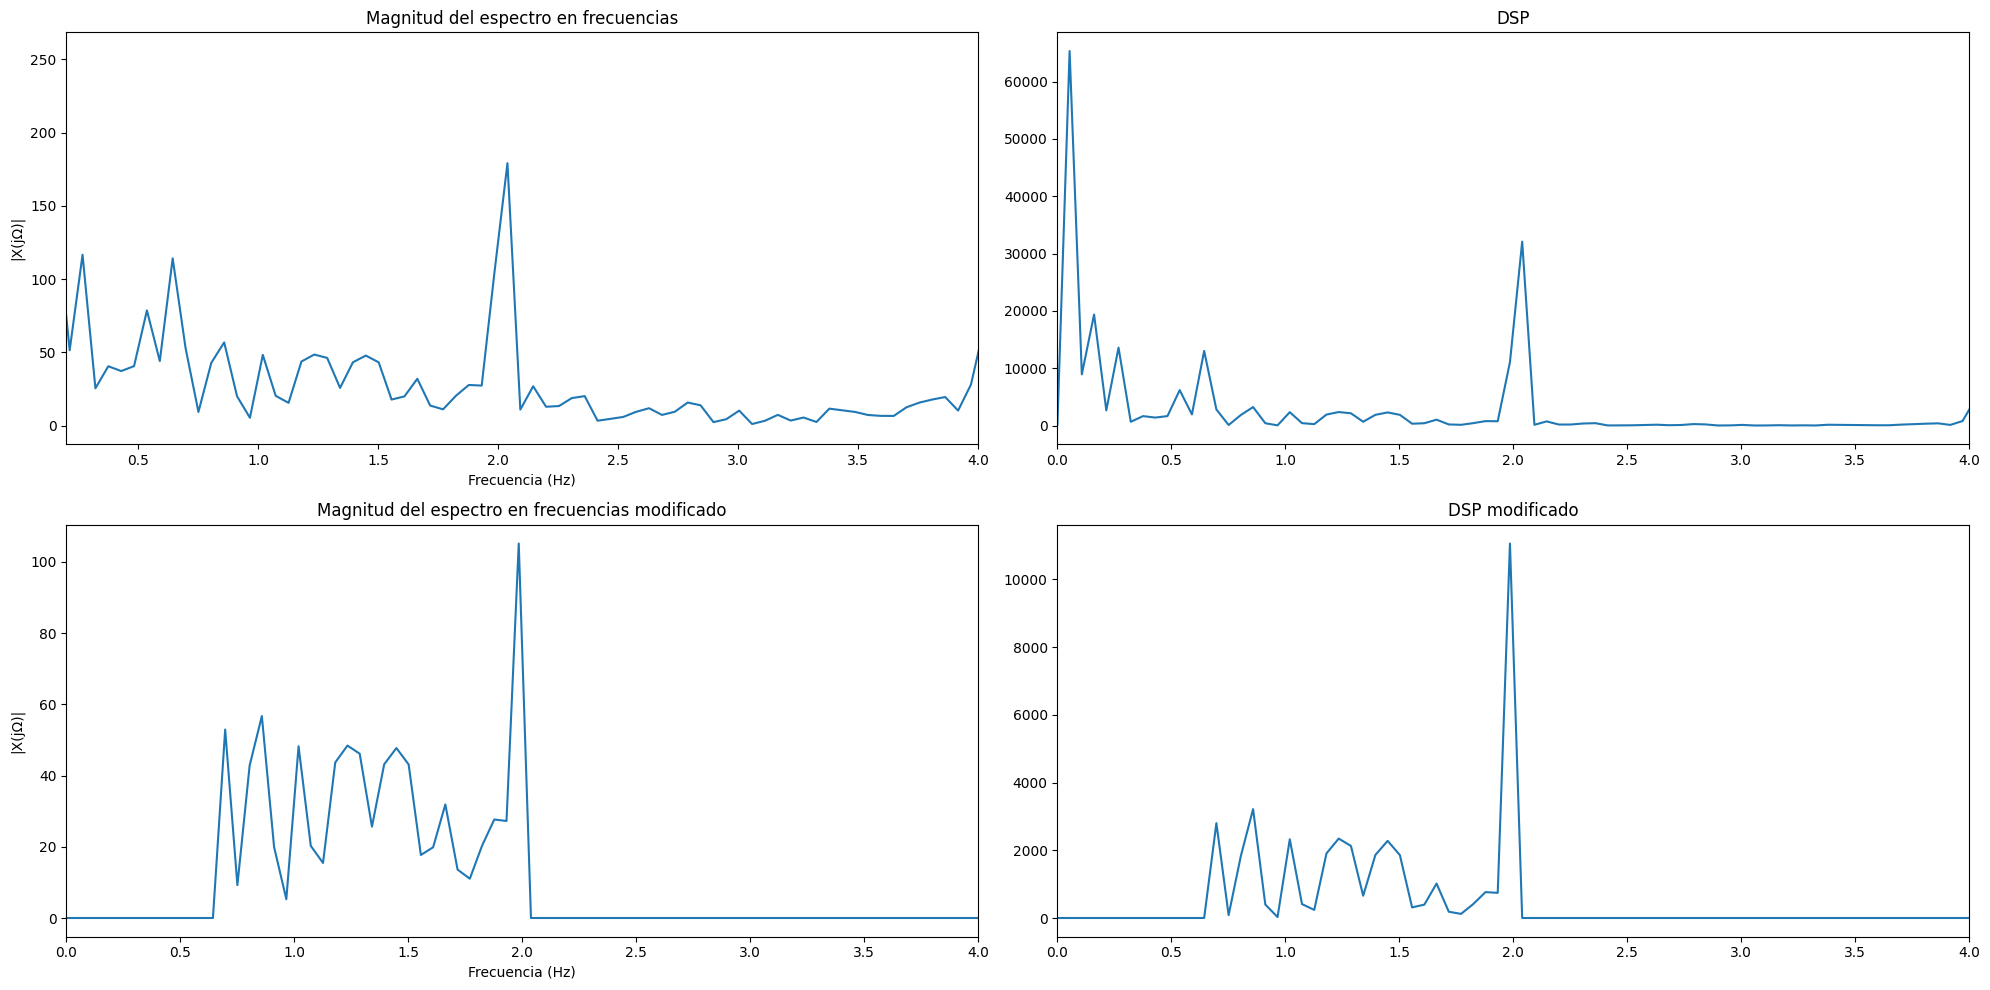

In [ ]:
#Magnitud del espectro en frecuencias
fs=30
x=offset
N1=len(x)
x_jomega=fft(x)
omega=fftfreq(N1,1/fps)
plt.figure()
plt.figure(figsize=(20, 10))
plt.subplot(2,2,1)
plt.plot((fftshift(omega)),fftshift(abs(x_jomega)))
plt.title('Magnitud del espectro en frecuencias')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X(jΩ)|')
plt.xlim([0.2,4])

#Densidad Espectral de Potencia
DSP=((abs(x_jomega))**2)
plt.subplot(2,2,2)
plt.plot((fftshift(omega)),fftshift(DSP))
plt.title('DSP')
plt.xlim(0,4)


#Filtro
X_jomega_modificado = x_jomega.copy()
X_jomega_modificado[(abs(omega) < 0.65)] = 0
X_jomega_modificado[(abs(omega) > 2)] = 0

#Magnitud del espectro en frecuencias modificado
plt.subplot(2,2,3)
plt.plot((fftshift(omega)),fftshift(abs(X_jomega_modificado)))
plt.title('Magnitud del espectro en frecuencias modificado')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X(jΩ)|')
plt.xlim([0,4])

#Densidad Espectral de Potencia modificado
DSP=((abs(X_jomega_modificado))**2)
plt.subplot(2,2,4)
plt.plot((fftshift(omega)),fftshift(DSP))
plt.title('DSP modificado')
plt.xlim(0,4)


plt.tight_layout()
plt.show()

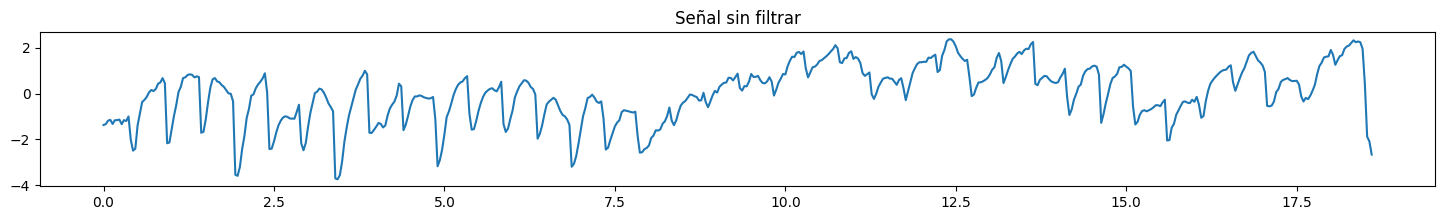

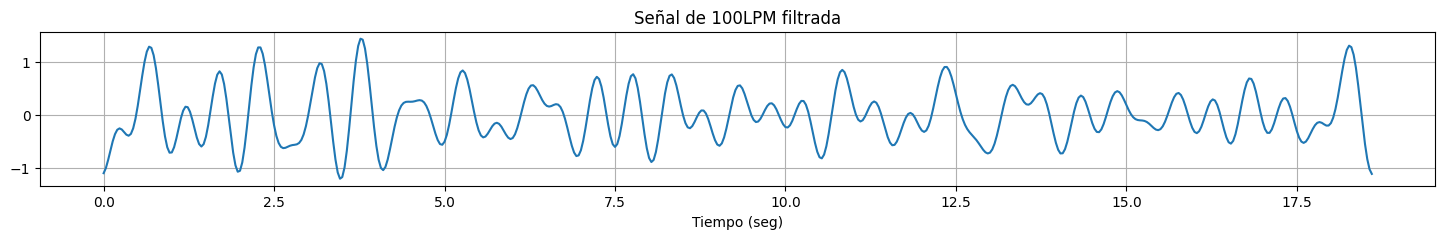

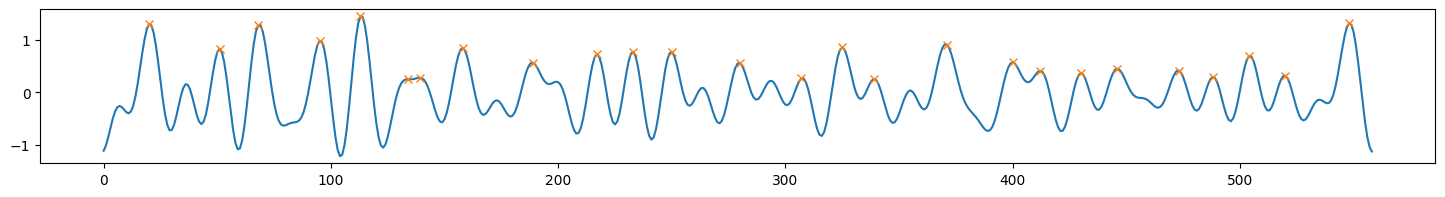

Frecuencia cardíaca promedio: 100.95 bpm


In [ ]:
t=np.arange(0,N1/fs,1/fs)

#Señal sin filtrar
plt.figure(figsize=(18,2))
plt.plot(t,offset)
plt.title('Señal sin filtrar')

#Señal filtrada
X_inversa=ifft(X_jomega_modificado)
plt.figure(figsize=(18,2))
plt.plot(t,X_inversa.real)
plt.title('Señal de 100LPM filtrada')
plt.xlabel('Tiempo (seg)')
plt.grid(True)

#Frecuencia cardiaca

#Encontrar los picos
peaks, _ = find_peaks(X_inversa.real, height=0.23)
plt.figure(figsize=(18,2))
plt.plot(X_inversa.real)
plt.plot(peaks, X_inversa.real[peaks], "x")
plt.show()

# Calcular los intervalos RR (diferencias entre los tiempos de los picos)
intervalos_RR = np.diff(peaks) / fs  # Intervalos en segundos

# Calcular la frecuencia cardíaca a partir de los intervalos RR
frecuencia_cardiaca = 60.0 / intervalos_RR  # Frecuencia en bpm (latidos por minuto)
frecuencia_cardiaca_promedio = np.mean(frecuencia_cardiaca)
print(f'Frecuencia cardíaca promedio: {frecuencia_cardiaca_promedio:.2f} bpm')

In [ ]:
# Detectar los picos en la señal
peaks, _ = find_peaks(X_inversa.real, height=0)

# Calcular el tiempo total de la señal en minutos
tiempo_total_minutos = t[-1] / 60.0

# Calcular el número total de picos
numero_de_picos = len(peaks)

# Calcular la frecuencia cardíaca promedio
frecuencia_cardiaca_promedio = numero_de_picos / tiempo_total_minutos

print(f'Frecuencia cardíaca promedio: {frecuencia_cardiaca_promedio:.2f} bpm')

Frecuencia cardíaca promedio: 100.00 bpm
